# TPC 1 – Regras de Associação

## Grupo 3 ou 4 não lembramos

### Paulo Alves
### Guilherme Pinho
### João
### Filipe

## Imports e file path

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime
from efficient_apriori import apriori

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

input_dir = './data_mba'
print('Ficheiros disponíveis:', os.listdir(input_dir))

Ficheiros disponíveis: ['order_products__train.csv', 'orders.csv', 'descriptive.txt', 'products.csv', 'desktop.ini', 'departments.csv', 'order_products__prior.csv', 'aisles.csv']


## Carregar os Dados

In [2]:
aisles_df               = pd.read_csv('./data_mba/aisles.csv')
orders_df               = pd.read_csv('./data_mba/orders.csv')
departments_df          = pd.read_csv('./data_mba/departments.csv')
products_df             = pd.read_csv('./data_mba/products.csv')
order_products_prior_df = pd.read_csv('./data_mba/order_products__prior.csv')
order_products_train_df = pd.read_csv('./data_mba/order_products__train.csv')

print('Dados carregados com sucesso!')
dataframes = {
    "aisles": aisles_df,
    "orders": orders_df,
    "departments": departments_df,
    "products": products_df,
    "order_products_prior": order_products_prior_df,
    "order_products_train": order_products_train_df
}

for name, df in dataframes.items():
    print(f"{name}: {df.shape}")

Dados carregados com sucesso!
aisles: (134, 2)
orders: (3421083, 7)
departments: (21, 2)
products: (49688, 4)
order_products_prior: (32434489, 4)
order_products_train: (1384617, 4)


## Preparação das Transações

Construção das transações por produto (necessário para o Apriori nas secções 6 e 7).

In [3]:
# Merge principal com departamentos e produtos
order_dep = order_products_prior_df.merge(products_df, on='product_id')
order_dep = order_dep.merge(departments_df, on='department_id')

# Transações por product_id
transactions_prod = order_products_prior_df.groupby('order_id')['product_id'].apply(tuple).tolist()

# Transações por departamento
transactions_dep = order_dep.groupby('order_id')['department'].apply(list).tolist()

print(f'Total de transações (produto): {len(transactions_prod)}')
print(f'Total de transações (departamento): {len(transactions_dep)}')

Total de transações (produto): 3214874
Total de transações (departamento): 3214874


## Aplicação do Algoritmo Apriori (supp=0.01, conf=0.2)

Geração das regras de associação base, usadas nas análises da Secção 6.

In [4]:
st = datetime.now()
itemsets_ap, rules_ap = apriori(transactions_prod[:100000], min_support=0.01, min_confidence=0.2)
print(f'Tempo de execução: {datetime.now() - st}')
print(f'Nº de regras encontradas: {len(rules_ap)}')

Tempo de execução: 0:00:00.512071
Nº de regras encontradas: 11


### Construção do DataFrame `df_rules_ap`

Conversão das regras para um DataFrame com suporte, confiança e lift, com os nomes dos produtos.

In [5]:
prod_map = products_df.set_index('product_id')['product_name'].to_dict()

rows = []
for rule in rules_ap:
    lhs = tuple(sorted(rule.lhs))
    rhs = tuple(sorted(rule.rhs))
    rows.append({
        'Product_A': [prod_map.get(i, i) for i in rule.lhs],
        'Product_B': [prod_map.get(i, i) for i in rule.rhs],
        'Support_A':  itemsets_ap[len(lhs)].get(lhs, 0) / 100000,
        'Support_B':  itemsets_ap[len(rhs)].get(rhs, 0) / 100000,
        'Support_AB': rule.support,
        'Confidence_AB': rule.confidence,
        'Lift_AB': rule.lift
    })

df_rules_ap = pd.DataFrame(rows)
print(f'Regras no DataFrame: {len(df_rules_ap)}')
df_rules_ap.head()

Regras no DataFrame: 11


,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
0,[Organic Strawberries],[Bag of Organic Bananas],0.08196,0.11961,0.01889,0.230478,1.926915
1,[Organic Baby Spinach],[Bag of Organic Bananas],0.07528,0.11961,0.01607,0.213470,1.784715
2,[Organic Raspberries],[Bag of Organic Bananas],0.04275,0.11961,0.01279,0.299181,2.501307
3,[Organic Hass Avocado],[Bag of Organic Bananas],0.06585,0.11961,0.01907,0.289598,2.421182
4,[Strawberries],[Banana],0.04427,0.14875,0.01288,0.290942,1.955912


---
# 6. Análise das Regras de Associação Encontradas

## 6a. Quantas/quais as regras de associação encontradas?

Total de regras geradas pelo Apriori (supp=0.01, conf=0.2) e a tabela completa com todas as regras.

In [6]:
print(f'Total de regras de associação encontradas: {len(df_rules_ap)}')
df_rules_ap

Total de regras de associação encontradas: 11


,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
0,[Organic Strawberries],[Bag of Organic Bananas],0.08196,0.11961,0.01889,0.230478,1.926915
1,[Organic Baby Spinach],[Bag of Organic Bananas],0.07528,0.11961,0.01607,0.213470,1.784715
2,[Organic Raspberries],[Bag of Organic Bananas],0.04275,0.11961,0.01279,0.299181,2.501307
3,[Organic Hass Avocado],[Bag of Organic Bananas],0.06585,0.11961,0.01907,0.289598,2.421182
4,[Strawberries],[Banana],0.04427,0.14875,0.01288,0.290942,1.955912
5,[Organic Strawberries],[Banana],0.08196,0.14875,0.01802,0.219863,1.478073
6,[Organic Raspberries],[Organic Strawberries],0.04275,0.08196,0.01015,0.237427,2.896863
7,[Organic Baby Spinach],[Banana],0.07528,0.14875,0.01629,0.216392,1.454737
8,[Organic Fuji Apple],[Banana],0.02757,0.14875,0.01035,0.375408,2.523752
9,[Large Lemon],[Banana],0.04737,0.14875,0.01289,0.272113,1.829332


## 6b. Quais as regras com maior confiança?


**Suporte (Support)**:  
Support(A, B) = frq (A, B) / N  
Onde frq (A, B) é a frequência de itens A e B juntos, e N é o total de transações.

---

**Confiança (Confidence)**:  
Confidence(A → B) = frq (A, B) / frq (A)  
A confiança mede a probabilidade de B acontecer, dado que A aconteceu.

---

**Lift**:  
Lift(A → B) = Support(A, B) / (Support(A) × Support(B))  
O lift mede a força da associação entre A e B em comparação com a independência.

---


A confiança mede a probabilidade de o antecedente (A) implicar o consequente (B): `conf(A→B) = frq(A∪B) / frq(A)`


In [7]:
df_rules_ap.sort_values(by='Confidence_AB', ascending=False).head(10)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
8,[Organic Fuji Apple],[Banana],0.02757,0.14875,0.01035,0.375408,2.523752
10,[Organic Avocado],[Banana],0.05432,0.14875,0.01663,0.306149,2.058143
2,[Organic Raspberries],[Bag of Organic Bananas],0.04275,0.11961,0.01279,0.299181,2.501307
4,[Strawberries],[Banana],0.04427,0.14875,0.01288,0.290942,1.955912
3,[Organic Hass Avocado],[Bag of Organic Bananas],0.06585,0.11961,0.01907,0.289598,2.421182
9,[Large Lemon],[Banana],0.04737,0.14875,0.01289,0.272113,1.829332
6,[Organic Raspberries],[Organic Strawberries],0.04275,0.08196,0.01015,0.237427,2.896863
0,[Organic Strawberries],[Bag of Organic Bananas],0.08196,0.11961,0.01889,0.230478,1.926915
5,[Organic Strawberries],[Banana],0.08196,0.14875,0.01802,0.219863,1.478073
7,[Organic Baby Spinach],[Banana],0.07528,0.14875,0.01629,0.216392,1.454737


## 6c. Quais as regras com maior suporte?

O suporte indica a frequência com que os itens A e B aparecem juntos nas transações. Regras com alto suporte são mais representativas do comportamento global dos clientes.

In [8]:
df_rules_ap.sort_values(by='Support_AB', ascending=False).head(10)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
3,[Organic Hass Avocado],[Bag of Organic Bananas],0.06585,0.11961,0.01907,0.289598,2.421182
0,[Organic Strawberries],[Bag of Organic Bananas],0.08196,0.11961,0.01889,0.230478,1.926915
5,[Organic Strawberries],[Banana],0.08196,0.14875,0.01802,0.219863,1.478073
10,[Organic Avocado],[Banana],0.05432,0.14875,0.01663,0.306149,2.058143
7,[Organic Baby Spinach],[Banana],0.07528,0.14875,0.01629,0.216392,1.454737
1,[Organic Baby Spinach],[Bag of Organic Bananas],0.07528,0.11961,0.01607,0.213470,1.784715
9,[Large Lemon],[Banana],0.04737,0.14875,0.01289,0.272113,1.829332
4,[Strawberries],[Banana],0.04427,0.14875,0.01288,0.290942,1.955912
2,[Organic Raspberries],[Bag of Organic Bananas],0.04275,0.11961,0.01279,0.299181,2.501307
8,[Organic Fuji Apple],[Banana],0.02757,0.14875,0.01035,0.375408,2.523752


## 6d. Quais as regras com maior lift?

O lift mede se a co-ocorrência de A e B é superior ao esperado por acaso: `lift(A→B) = conf(A→B) / frq(B)`. Valores > 1 indicam associação positiva.

In [9]:
df_rules_ap.sort_values(by='Lift_AB', ascending=False).head(10)

,Product_A,Product_B,Support_A,Support_B,Support_AB,Confidence_AB,Lift_AB
6,[Organic Raspberries],[Organic Strawberries],0.04275,0.08196,0.01015,0.237427,2.896863
8,[Organic Fuji Apple],[Banana],0.02757,0.14875,0.01035,0.375408,2.523752
2,[Organic Raspberries],[Bag of Organic Bananas],0.04275,0.11961,0.01279,0.299181,2.501307
3,[Organic Hass Avocado],[Bag of Organic Bananas],0.06585,0.11961,0.01907,0.289598,2.421182
10,[Organic Avocado],[Banana],0.05432,0.14875,0.01663,0.306149,2.058143
4,[Strawberries],[Banana],0.04427,0.14875,0.01288,0.290942,1.955912
0,[Organic Strawberries],[Bag of Organic Bananas],0.08196,0.11961,0.01889,0.230478,1.926915
9,[Large Lemon],[Banana],0.04737,0.14875,0.01289,0.272113,1.829332
1,[Organic Baby Spinach],[Bag of Organic Bananas],0.07528,0.11961,0.01607,0.213470,1.784715
5,[Organic Strawberries],[Banana],0.08196,0.14875,0.01802,0.219863,1.478073


## 6e. Quais as implicações de estratégias de marketing nas vendas?

As regras de associação identificadas revelam padrões de compra recorrentes nos consumidores, mostrando quais os produtos que tendem a ser adquiridos em conjunto numa mesma transação. Esta informação tem um valor estratégico considerável, uma vez que permite tomar decisões de marketing mais informadas e direcionadas.

Uma das aplicações mais diretas é o cross-selling, isto é, a sugestão automática de produtos complementares no momento em que o cliente está a fazer uma compra. Se uma regra de associação indica que os clientes que compram o produto A tendem também a comprar o produto B com elevada confiança, faz sentido exibir o produto B como sugestão quando o produto A é adicionado ao carrinho. Esta estratégia aumenta o valor médio por transação sem forçar a compra, pois baseia-se num comportamento já observado.

Outra implicação relevante é a criação de promoções conjuntas ou bundles. Produtos com suporte elevado, ou seja, que aparecem juntos com muita frequência, são candidatos naturais a descontos combinados ou pacotes promocionais. Para além de incentivar a compra, esta abordagem reforça a perceção de valor por parte do consumidor, que sente estar a beneficiar de uma oferta pensada para as suas necessidades.

As regras com lift elevado merecem especial atenção do ponto de vista do marketing. Um lift superior a 1 indica que a co-ocorrência dos dois produtos é significativamente superior ao que seria esperado por acaso, sugerindo uma associação genuína entre eles. Estes pares representam oportunidades de promoção cruzada de alto impacto, pois existe uma relação real entre os produtos e não apenas uma coincidência estatística. Por exemplo pão e manteiga ou cerveja e fraudas num certo dia. O problema que foi mostrado em aula.

A nível do layout da loja física ou da navegação num site de e-commerce, as regras de associação podem orientar o posicionamento dos produtos. Colocar produtos frequentemente comprados em conjunto nas mesmas prateleiras ou em secções próximas reduz o esforço do cliente e aumenta a probabilidade de compra simultânea ou então colocar as que tem uma relação muito forte colocar na loja fisica muito distantes, pois assim o cliente tem de percorrer outros corredores e acabar por comprar produtos que não precisa, aumentado assim o lucro do negócio. No contexto digital, isto traduz-se em categorias recomendadas, banners contextuais ou notificações personalizadas. Finalmente, do ponto de vista operacional, conhecer os padrões de co-compra permite uma melhor gestão de stock, uma vez que a escassez de um produto pode afetar indiretamente as vendas do outro com o qual é frequentemente adquirido.

Todas estas estrategias podem ter um efeito positivo na receita e na eficiência operacional. Para um negócio é de extrema importante perceber estas relações.

---
# 7.

## 7a. Quais as famílias de produtos mais comprados?

Agrupamos os produtos por departamento e contamos o número de linhas em `order_products_prior`, que representa cada produto comprado num pedido.

Top 10 Famílias de Produtos Mais Comprados:
department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627


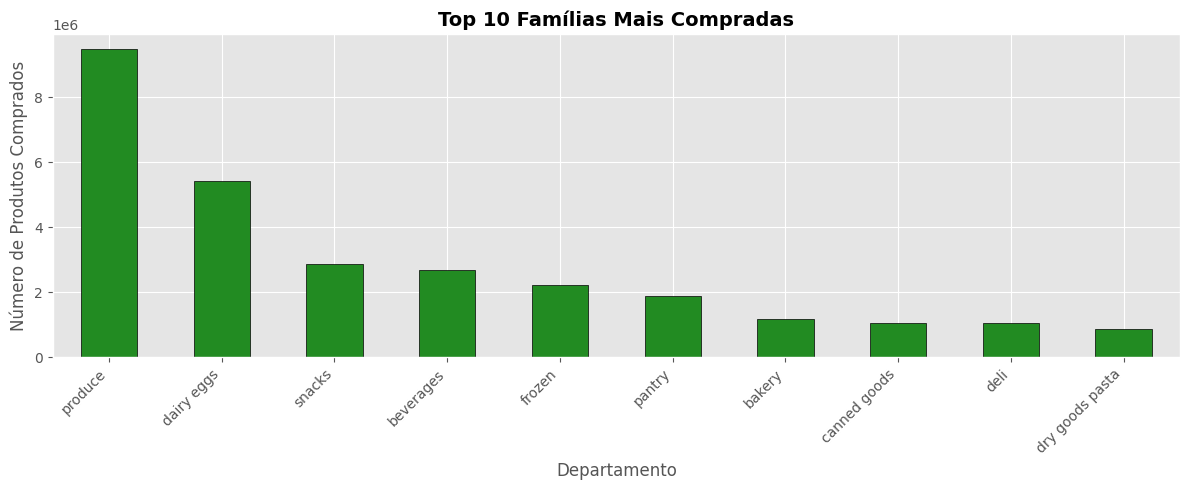

In [10]:
familias = order_dep['department'].value_counts()

print('Top 10 Famílias de Produtos Mais Comprados:')
print(familias.head(10).to_string())

familias.head(10).plot(kind='bar', figsize=(12, 5), color='forestgreen', edgecolor='black')
plt.title('Top 10 Famílias Mais Compradas', fontsize=14, fontweight='bold')
plt.ylabel('Número de Produtos Comprados')
plt.xlabel('Departamento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7b. Quais e quantas regras de associação existem entre as diferentes famílias de produtos?

Experimentamos 5 conjuntos de suporte/confiança sobre transações ao nível do **departamento**:

| # | Suporte | Confiança | Justificação |
|---|---------|-----------|---------------|
| 1 | 0.01    | 0.20      | Ponto de partida equilibrado |
| 2 | 0.015   | 0.25      | Mais restritivo - regras mais fiáveis |
| 3 | 0.005   | 0.15      | Mais permissivo - capta associações menos frequentes |
| 4 | 0.08    | 0.20      | Suporte muito alto - apenas associações muito comuns |
| 5 | 0.05    | 0.15      | Suporte moderado, confiança baixa - mais regras, menor qualidade |

À medida que se reduz o suporte mínimo, o número de regras cresce significativamente. A escolha ideal depende do contexto de negócio e do grau de confiança exigido.

In [33]:
configs = [
    (0.10,  0.05, 'Produtos muito frquentes mas com regras fracas'),
    (0.005, 0.85, 'Produtos que menos aparecem, mas com alta confiança'),
    (0.015, 0.15, 'Frquentes mas com alguma associação'),
    (0.005,  0.30, 'Equilibrio'),
    (0.002,  0.55, 'Regras fortes mais raras'),
]

for supp, conf, descricao in configs:
    _, rules_d = apriori(transactions_dep[:100000], min_support=supp, min_confidence=conf)
    print(f'[{descricao}] supp={supp}, conf={conf} → {len(rules_d)} regras')
    for r in list(rules_d)[:2]:
        print(f'   {r}')
    print()

[Produtos muito frquentes mas com regras fracas] supp=0.1, conf=0.05 → 438 regras
   {beverages} -> {bakery} (conf: 0.310, supp: 0.141, lift: 1.133, conv: 1.053)
   {bakery} -> {beverages} (conf: 0.515, supp: 0.141, lift: 1.133, conv: 1.125)

[Produtos que menos aparecem, mas com alta confiança] supp=0.005, conf=0.85 → 6316 regras
   {bulk} -> {produce} (conf: 0.895, supp: 0.010, lift: 1.195, conv: 2.393)
   {canned goods} -> {produce} (conf: 0.879, supp: 0.186, lift: 1.173, conv: 2.069)

[Frquentes mas com alguma associação] supp=0.015, conf=0.15 → 26842 regras
   {babies} -> {bakery} (conf: 0.379, supp: 0.021, lift: 1.386, conv: 1.170)
   {babies} -> {beverages} (conf: 0.496, supp: 0.027, lift: 1.093, conv: 1.083)

[Equilibrio] supp=0.005, conf=0.3 → 80271 regras
   {alcohol} -> {beverages} (conf: 0.501, supp: 0.013, lift: 1.102, conv: 1.093)
   {alcohol} -> {dairy eggs} (conf: 0.510, supp: 0.013, lift: 0.753, conv: 0.658)

[Regras fortes mais raras] supp=0.002, conf=0.55 → 73587 reg

## 7c. Principais diferenças nas associações entre dias da semana/fim de semana

Dividimos os pedidos em **semana** considerando segunda como 0 (order_dow  {0,1,2,3,4}) e **fim de semana** (order_dow  {5,6}) e analisamos os produtos mais comprados e as regras de associação em cada período.

product_name
Banana                    312482
Bag of Organic Bananas    258710
Organic Strawberries      174129
Organic Baby Spinach      151883
Organic Hass Avocado      141127
Organic Avocado           111848
Large Lemon                96605
Strawberries               96378
Organic Whole Milk         92248
Organic Raspberries        92159
Name: count, dtype: int64
product_name
Banana                    160083
Bag of Organic Bananas    120740
Organic Strawberries       90554
Organic Baby Spinach       90038
Organic Hass Avocado       72457
Organic Avocado            64967
Large Lemon                56052
Limes                      52686
Strawberries               46573
Organic Whole Milk         45657
Name: count, dtype: int64


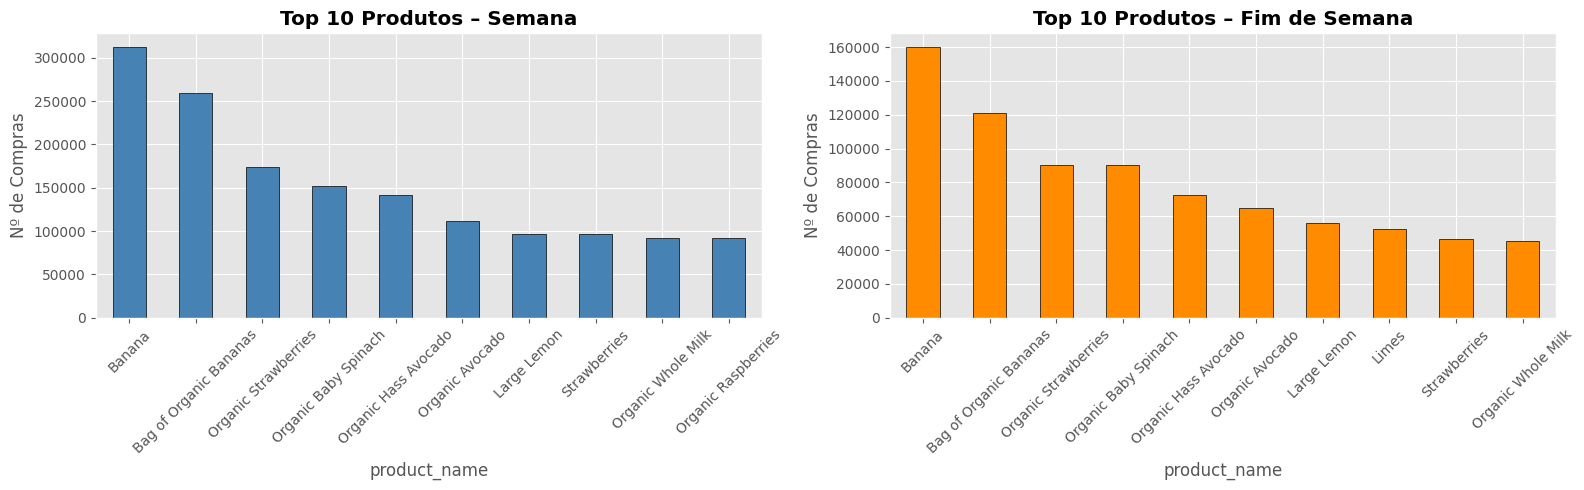

In [22]:
order_full = order_products_prior_df.merge(orders_df, on='order_id')
order_full = order_full.merge(products_df[['product_name','product_id']], on='product_id')

weekday_orders = order_full[order_full['order_dow'].isin([1, 2, 3, 4, 5])]
weekend_orders = order_full[order_full['order_dow'].isin([0, 6])]

weekday_counts = weekday_orders['product_name'].value_counts()
weekend_counts = weekend_orders['product_name'].value_counts()

print(weekday_counts.head(10))
print(weekend_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

weekday_counts.head(10).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 10 Produtos – Semana', fontweight='bold')
axes[0].set_ylabel('Nº de Compras')
axes[0].tick_params(axis='x', rotation=45)

weekend_counts.head(10).plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Top 10 Produtos – Fim de Semana', fontweight='bold')
axes[1].set_ylabel('Nº de Compras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Regras de associação por período
trans_weekday = weekday_orders.groupby('order_id')['product_name'].apply(tuple).tolist()
trans_weekend = weekend_orders.groupby('order_id')['product_name'].apply(tuple).tolist()

_, rules_weekday = apriori(trans_weekday[:100000], min_support=0.01, min_confidence=0.2)
_, rules_weekend = apriori(trans_weekend[:100000], min_support=0.01, min_confidence=0.2)

print(f'Regras de associação – Semana:      {len(rules_weekday)}')
print(f'Regras de associação – Fim de Semana: {len(rules_weekend)}')

print('\n--- Top 5 Semana (confiança) ---')
for r in sorted(rules_weekday, key=lambda x: x.confidence, reverse=True)[:5]:
    print(f'  {r}  conf={r.confidence:.3f}  supp={r.support:.4f}')

print('\n--- Top 5 Fim de Semana (confiança) ---')
for r in sorted(rules_weekend, key=lambda x: x.confidence, reverse=True)[:5]:
    print(f'  {r}  conf={r.confidence:.3f}  supp={r.support:.4f}')

Regras de associação – Semana:      12
Regras de associação – Fim de Semana: 12

--- Top 5 Semana (confiança) ---
  {Organic Fuji Apple} -> {Banana} (conf: 0.382, supp: 0.011, lift: 2.561, conv: 1.376)  conf=0.382  supp=0.0106
  {Cucumber Kirby} -> {Banana} (conf: 0.339, supp: 0.010, lift: 2.277, conv: 1.288)  conf=0.339  supp=0.0102
  {Organic Raspberries} -> {Bag of Organic Bananas} (conf: 0.305, supp: 0.013, lift: 2.540, conv: 1.266)  conf=0.305  supp=0.0129
  {Organic Avocado} -> {Banana} (conf: 0.301, supp: 0.016, lift: 2.018, conv: 1.217)  conf=0.301  supp=0.0163
  {Organic Hass Avocado} -> {Bag of Organic Bananas} (conf: 0.292, supp: 0.020, lift: 2.431, conv: 1.243)  conf=0.292  supp=0.0198

--- Top 5 Fim de Semana (confiança) ---
  {Organic Avocado} -> {Banana} (conf: 0.304, supp: 0.016, lift: 2.101, conv: 1.229)  conf=0.304  supp=0.0164
  {Strawberries} -> {Banana} (conf: 0.298, supp: 0.013, lift: 2.060, conv: 1.219)  conf=0.298  supp=0.0133
  {Organic Hass Avocado} -> {Bag of

## 7d. Quais os clientes vegetarianos e vegans?

Utilizamos uma aproximação baseada nos departamentos comprados:

- **Vegetariano**: comprou `dairy eggs` mas **nunca** `meat seafood`
- **Vegan**: nunca comprou `dairy eggs` nem `meat seafood`

> *Nota*: Esta é uma aproximação — não lidamos com os clientes que apenas compraram uma ou poucas vezes produtos vegan/vegetarianos.

In [ ]:
customer_dep = order_dep.merge(orders_df[['order_id', 'user_id']], on='order_id')

todos_clientes  = set(customer_dep['user_id'])
clientes_dairy  = set(customer_dep[customer_dep['department'] == 'dairy eggs']['user_id'])
clientes_meat_seafood   = set(customer_dep[customer_dep['department'] == 'meat seafood']['user_id'])

vegetarians = clientes_dairy - clientes_meat_seafood
vegans      = todos_clientes - clientes_dairy - clientes_meat_seafood
others      = todos_clientes - vegetarians - vegans

print(f'Total de clientes:   {len(todos_clientes)}')
print(f'Vegetarianos:        {len(vegetarians)}')
print(f'Vegans:              {len(vegans)}')
print(f'Outros:              {len(others)}')
print(f'\nIDs vegetarianos (primeiros 20): {sorted(vegetarians)[:20]}')
print(f'IDs vegans (primeiros 20):       {sorted(vegans)[:20]}')

Total de clientes:   206209
Vegetarianos:        79092
Vegans:              13226
Outros:              113891

IDs vegetarianos (primeiros 20): [1, 3, 5, 8, 11, 13, 17, 21, 26, 27, 29, 33, 34, 35, 36, 42, 45, 50, 52, 53]
IDs vegans (primeiros 20):       [4, 15, 20, 30, 92, 113, 120, 139, 170, 195, 196, 209, 218, 249, 271, 287, 311, 318, 326, 331]


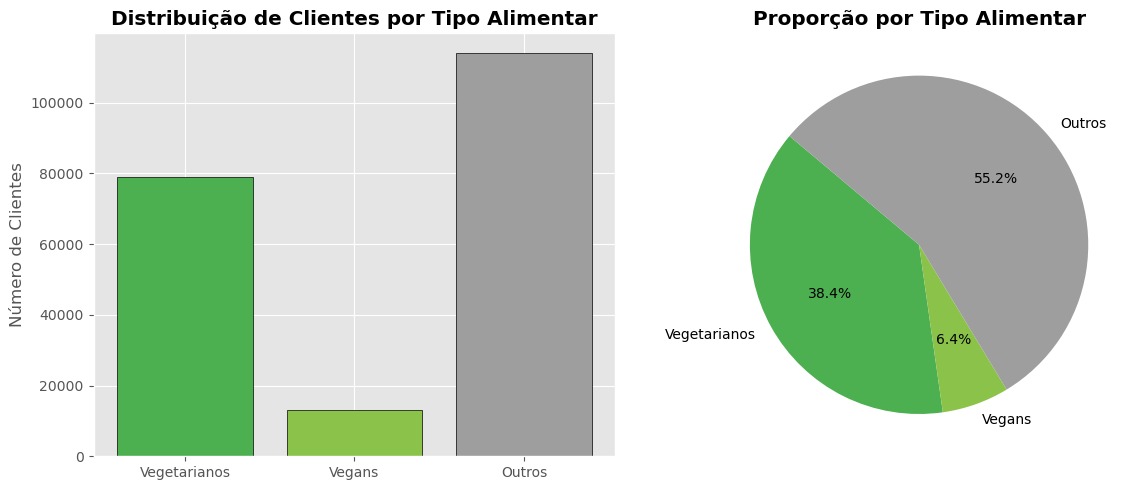

In [ ]:
labels = ['Vegetarianos', 'Vegans', 'Outros']
values = [len(vegetarians), len(vegans), len(others)]
colors = ['#4caf50', '#8bc34a', '#9e9e9e']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, values, color=colors, edgecolor='black')
axes[0].set_title('Distribuição de Clientes por Tipo Alimentar', fontweight='bold')
axes[0].set_ylabel('Número de Clientes')

axes[1].pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proporção por Tipo Alimentar', fontweight='bold')

plt.tight_layout()
plt.show()

## 7e. Regras de associação: recompras vs. primeira compra

Separamos as transações em dois grupos:
- **Recompras** (`reordered == 1`): produtos que o cliente já tinha comprado anteriormente
- **Primeira compra** (`reordered == 0`): produtos adquiridos pela primeira vez

Calculamos as regras de Apriori para cada grupo e apresentamos as **5 com maior confiança** e as **5 com maior suporte**.

In [ ]:
# Calcule as regras de associação somente entre os produtos que foram comprados várias vezes e aqueles que
# foram comprados pela primeira vez. Quais são as 5 regras com maior confiança? Quais são as 5 regras com
# maior suporte?
order_FR = order_products_prior_df.merge(products_df[['product_name', 'product_id']], on="product_id")

order_FR['tag'] = order_FR['product_name'] + '_' + \
                  order_FR['reordered'].map({0: 'FIRST', 1: 'REP'})

trans_repeated = order_FR.groupby('order_id')['tag'].apply(list).tolist()

itemsetsR, rulesRepeated = apriori(trans_repeated[:100000], min_support=0.0005, min_confidence=0.2, max_length=2)

In [30]:
cross_rules = []

for r in rulesRepeated:
    lhs = list(r.lhs)
    rhs = list(r.rhs)

    if any('_FIRST' in i for i in lhs) and any('_REP' in i for i in rhs):
        cross_rules.append(r)
    elif any('_REP' in i for i in lhs) and any('_FIRST' in i for i in rhs):
        cross_rules.append(r)

In [31]:
top_conf = sorted(cross_rules,
                  key=lambda x: x.confidence,
                  reverse=True)[:5]

top_supp = sorted(cross_rules,
                  key=lambda x: x.support,
                  reverse=True)[:5]

In [32]:
print("Top 5 Confiança - FIRST ↔ REP")
for r in top_conf:
    print(r)

print("\nTop 5 Suporte - FIRST ↔ REP")
for r in top_supp:
    print(r)

Top 5 Confiança - FIRST ↔ REP
{Berry Medley_FIRST} -> {Banana_REP} (conf: 0.255, supp: 0.001, lift: 2.033, conv: 1.174)
{Organic Dijon Mustard_FIRST} -> {Banana_REP} (conf: 0.214, supp: 0.001, lift: 1.710, conv: 1.113)
{Organic Green Seedless Grapes_FIRST} -> {Organic Strawberries_REP} (conf: 0.209, supp: 0.001, lift: 3.299, conv: 1.184)
{Honeycrisp Apple_FIRST} -> {Banana_REP} (conf: 0.205, supp: 0.002, lift: 1.633, conv: 1.100)
{Red Raspberries_FIRST} -> {Banana_REP} (conf: 0.203, supp: 0.001, lift: 1.623, conv: 1.098)

Top 5 Suporte - FIRST ↔ REP
{Honeycrisp Apple_FIRST} -> {Banana_REP} (conf: 0.205, supp: 0.002, lift: 1.633, conv: 1.100)
{Broccoli Crown_FIRST} -> {Banana_REP} (conf: 0.200, supp: 0.001, lift: 1.600, conv: 1.094)
{Red Raspberries_FIRST} -> {Banana_REP} (conf: 0.203, supp: 0.001, lift: 1.623, conv: 1.098)
{Berry Medley_FIRST} -> {Banana_REP} (conf: 0.255, supp: 0.001, lift: 2.033, conv: 1.174)
{Organic Dijon Mustard_FIRST} -> {Banana_REP} (conf: 0.214, supp: 0.001, li

## 7f. As 3 regras com maior suporte e confiança para cada hora do dia

Para cada hora do dia (0–23) calculamos as regras de associação e apresentamos as 3 com melhor combinação de suporte e confiança.

**Conclusões esperadas:**
- **Manhã (6h–11h)**: associações com produtos de pequeno-almoço (frutas, leite, pão, iogurtes)
- **Meio-dia / tarde (12h–18h)**: produtos para refeições rápidas, snacks e bebidas
- **Noite (19h–23h)**: compras de jantar, proteínas e vegetais frescos
- **Madrugada (0h–5h)**: volume muito baixo, regras menos representativas e fiáveis

In [ ]:
order_hour = orders_df.merge(order_products_prior_df, on='order_id')
order_hour = order_hour.merge(products_df[['product_name','product_id']], on='product_id')

for hora in range(24):
    subset = order_hour[order_hour['order_hour_of_day'] == hora]
    trans  = subset.groupby('order_id')['product_name'].apply(tuple).tolist()

    if len(trans) < 50:
        print(f'\n=== {hora:02d}h | dados insuficientes ({len(trans)} transações) ===')
        continue

    _, rulesH = apriori(trans[:50000], min_support=0.01, min_confidence=0.2)
    rulesH_sorted = sorted(rulesH, key=lambda x: (x.support + x.confidence), reverse=True)

    print(f'\n=== {hora:02d}h | {len(trans)} transações | {len(rulesH)} regras ===')
    for r in rulesH_sorted[:3]:
        print(f'  {r}  supp={r.support:.4f}  conf={r.confidence:.3f}  lift={r.lift:.3f}')


=== 00h | 21372 transações | 9 regras ===
  {Organic Hass Avocado} -> {Bag of Organic Bananas} (conf: 0.297, supp: 0.019, lift: 2.339, conv: 1.242)  supp=0.0194  conf=0.297  lift=2.339
  {Organic Raspberries} -> {Bag of Organic Bananas} (conf: 0.298, supp: 0.013, lift: 2.350, conv: 1.244)  supp=0.0128  conf=0.298  lift=2.350
  {Cucumber Kirby} -> {Banana} (conf: 0.298, supp: 0.010, lift: 2.260, conv: 1.236)  supp=0.0102  conf=0.298  lift=2.260

=== 01h | 11596 transações | 5 regras ===
  {Organic Hass Avocado} -> {Bag of Organic Bananas} (conf: 0.292, supp: 0.017, lift: 2.454, conv: 1.245)  supp=0.0172  conf=0.292  lift=2.454
  {Organic Raspberries} -> {Bag of Organic Bananas} (conf: 0.291, supp: 0.011, lift: 2.442, conv: 1.242)  supp=0.0106  conf=0.291  lift=2.442
  {Organic Strawberries} -> {Bag of Organic Bananas} (conf: 0.260, supp: 0.019, lift: 2.184, conv: 1.191)  supp=0.0195  conf=0.260  lift=2.184

=== 02h | 7070 transações | 5 regras ===
  {Organic Raspberries} -> {Bag of Org